# Day 18 · Colab 1 — Claude Agent + FastAPI Backend + Redis Memory

**Agentic Systems Bootcamp**

In this notebook you build a small but complete **tool-using agent**:

- a **FastAPI** backend exposing an `/orders/{id}` endpoint (your *external API*),
- a **Redis** memory layer (short-term conversation history + long-term facts),
- a **Claude** agent that calls tools in a `while` loop driven by `stop_reason`.

Everything runs **inside Colab** with no external servers:
`fakeredis` stands in for Redis and FastAPI's `TestClient` calls the API in-process.
Swap either for the real thing by changing one line each (shown at the end).

> **Pattern recap (from the deck):** client tools return `stop_reason="tool_use"`; *your* code runs the
> tool and returns a `tool_result` block; you loop until `stop_reason="end_turn"`.

## Step 1 — Install dependencies & set your API key

`fakeredis` gives us a real Redis API surface in-process. `httpx` is needed by FastAPI's test client.

In [1]:
%%capture
!pip install -q anthropic fastapi 'httpx<0.28' fakeredis 2>/dev/null
print('deps installed')

In [2]:
import os, getpass

# In Colab, prefer the Secrets panel (key icon) named ANTHROPIC_API_KEY.
if not os.environ.get('ANTHROPIC_API_KEY'):
    try:
        from google.colab import userdata
        os.environ['ANTHROPIC_API_KEY'] = userdata.get('ANTHROPIC_API_KEY')
    except Exception:
        pass

if not os.environ.get('ANTHROPIC_API_KEY'):
    # Fallback: paste it (hidden). Leave blank to run in OFFLINE mock mode.
    os.environ['ANTHROPIC_API_KEY'] = getpass.getpass('ANTHROPIC_API_KEY (blank = offline mock): ')

LIVE = bool(os.environ.get('ANTHROPIC_API_KEY'))
MODEL = 'claude-sonnet-4-6'  # fast + cheap for a workshop; opus-4-8 for harder reasoning
print('LIVE mode' if LIVE else 'OFFLINE mock mode (no key) — agent loop will be simulated')

LIVE mode


## Step 2 — A tiny FastAPI backend (the 'external API')

This is the kind of service your agent does **not** control — it just calls it.
We expose one route, then wrap the app in a `TestClient` so calls run in-process.

In [3]:
from fastapi import FastAPI, HTTPException
from fastapi.testclient import TestClient

app = FastAPI()

_ORDERS = {
    'A1001': {'id': 'A1001', 'item': 'Mechanical keyboard', 'qty': 1, 'status': 'shipped',  'total': 129.0},
    'A1002': {'id': 'A1002', 'item': 'USB-C hub',          'qty': 2, 'status': 'processing','total': 58.0},
    'A1003': {'id': 'A1003', 'item': '4K monitor',         'qty': 1, 'status': 'delivered', 'total': 410.0},
}

@app.get('/orders/{order_id}')
def get_order(order_id: str):
    o = _ORDERS.get(order_id.upper())
    if not o:
        raise HTTPException(status_code=404, detail='order not found')
    return o

client = TestClient(app)
print(client.get('/orders/A1001').json())

{'id': 'A1001', 'item': 'Mechanical keyboard', 'qty': 1, 'status': 'shipped', 'total': 129.0}


## Step 3 — A Redis memory layer

Two responsibilities, the way the deck framed memory:

- **Short-term** — the running conversation, stored as a Redis **list** per session (`hist:<session>`).
- **Long-term** — durable **facts** about the user, stored in a Redis **hash** (`facts:<session>`), with an optional TTL.

`fakeredis` implements the same commands, so this class is unchanged when you move to real Redis.

In [40]:
import json, time, fakeredis, redis

class RedisMemory:
    def __init__(self, r, session_id: str, history_limit: int = 40):
        self.r = r
        self.sid = session_id
        self.history_limit = history_limit
        self.h_key = f'hist:{session_id}'
        self.f_key = f'facts:{session_id}'

    # ---- short-term: conversation turns ----
    def append_turn(self, role: str, content):
        self.r.rpush(self.h_key, json.dumps({'role': role, 'content': content}))
        self.r.ltrim(self.h_key, -self.history_limit, -1)  # keep only the tail

    def load_history(self):
        return [json.loads(x) for x in self.r.lrange(self.h_key, 0, -1)]

    # ---- long-term: durable facts ----
    def set_fact(self, key: str, value: str, ttl_seconds: int | None = None):
        self.r.hset(self.f_key, key, value)
        if ttl_seconds:
            self.r.expire(self.f_key, ttl_seconds)

    def get_fact(self, key: str):
        v = self.r.hget(self.f_key, key)
        return v.decode() if isinstance(v, bytes) else v

    def all_facts(self):
         return {
        k: v
        for k, v in self.r.hgetall(self.f_key).items()
    }

# r = fakeredis.FakeStrictRedis()
# Calling actual redis instead of FakeRedis for Extension-6
os.environ["REDIS_URL"] = \
"redis://localhost:6379"
r = redis.Redis.from_url(
    os.environ["REDIS_URL"],
    decode_responses=True
)
mem = RedisMemory(r, session_id='demo-user')
mem.set_fact('name', 'Asha')
mem.append_turn('user', 'hello')
print('facts:', mem.all_facts())
print('history:', mem.load_history())

facts: {'name': 'Asha'}
history: [{'role': 'user', 'content': 'hello'}, {'role': 'user', 'content': 'hello'}]


In [30]:
%%capture
!pip install redis

## Step 4 — Declare the tools (JSON schemas)

Three client tools. Names are **namespaced by purpose** and every field is described —
the description *is* the prompt the model reads when deciding how to call.
`order_id` uses a `pattern` so the model returns well-formed IDs.

In [5]:
TOOLS = [
    {
        'name': 'get_order',
        'description': 'Look up a customer order by its ID and return item, quantity, status and total.',
        'input_schema': {
            'type': 'object',
            'properties': {
                'order_id': {'type': 'string', 'description': "Order ID like 'A1001'.", 'pattern': '^[Aa][0-9]{4}$'}
            },
            'required': ['order_id'],
        },
    },
    {
        'name': 'remember_fact',
        'description': 'Persist a durable fact about the user (e.g. shipping preference) for future turns.',
        'input_schema': {
            'type': 'object',
            'properties': {
                'key':   {'type': 'string', 'description': 'Short fact key, e.g. "shipping_pref".'},
                'value': {'type': 'string', 'description': 'The fact value to store.'},
            },
            'required': ['key', 'value'],
        },
    },
    {
        'name': 'recall_fact',
        'description': 'Retrieve a previously stored fact about the user by key. Returns empty if unknown.',
        'input_schema': {
            'type': 'object',
            'properties': {'key': {'type': 'string', 'description': 'The fact key to look up.'}},
            'required': ['key'],
        },
    },
]
print(len(TOOLS), 'tools declared')

3 tools declared


## Step 5 — A dispatch map: tool name → Python function

This is the boundary between *the model's intent* and *your code*. Each function returns a
string (what the model will read back). Errors are **returned**, not raised, so the agent can recover —
that maps to `is_error: true` on the `tool_result` block in Step 6.

In [6]:
def tool_get_order(order_id: str):
    resp = client.get(f'/orders/{order_id}')
    if resp.status_code == 404:
        return {'error': f'No order {order_id} found.'}
    resp.raise_for_status()
    return resp.json()

def tool_remember_fact(key: str, value: str):
    mem.set_fact(key, value)
    return {'ok': True, 'stored': {key: value}}

def tool_recall_fact(key: str):
    v = mem.get_fact(key)
    return {'key': key, 'value': v} if v is not None else {'key': key, 'value': None}

DISPATCH = {
    'get_order': tool_get_order,
    'remember_fact': tool_remember_fact,
    'recall_fact': tool_recall_fact,
}

def run_tool(name, args):
    fn = DISPATCH.get(name)
    if fn is None:
        return {'error': f'unknown tool {name}'}, True
    try:
        out = fn(**args)
        is_err = isinstance(out, dict) and 'error' in out
        return out, is_err
    except Exception as e:
        return {'error': repr(e)}, True

print(run_tool('get_order', {'order_id': 'A1002'}))
print(run_tool('get_order', {'order_id': 'A9999'}))

({'id': 'A1002', 'item': 'USB-C hub', 'qty': 2, 'status': 'processing', 'total': 58.0}, False)
({'error': 'No order A9999 found.'}, True)


## Step 6 — The agent loop (driven by `stop_reason`)

This is the heart of client-side tool use:

1. send messages + tool definitions,
2. if `stop_reason == 'tool_use'`: run **every** `tool_use` block, append a single user message
   containing one `tool_result` per call (matched by `tool_use_id`), and loop,
3. stop at `stop_reason == 'end_turn'` and return the text.

If there's no API key we simulate one scripted tool call so the notebook still runs end-to-end.

In [28]:
import json

SYSTEM = (
    'You are an order-support assistant. Use get_order for any order question. '
    'Use remember_fact / recall_fact to keep durable user preferences across turns. '
    'Be concise.'
)

# Added for Token Count of Extension-5
total_input_tokens = 0
total_output_tokens = 0

def agent_turn(user_text, max_steps=6, verbose=True):
    mem.append_turn('user', user_text)
    messages = mem.load_history()

    global total_input_tokens
    global total_output_tokens
    if not LIVE:
        # ---- offline mock: pretend the model asked for get_order once ----
        if verbose: print('… (mock) model requests get_order A1001')
        out, _ = run_tool('get_order', {'order_id': 'A1001'})
        reply = f'(mock) Order A1001 is {out.get("status", "?")}.'
        mem.append_turn('assistant', reply)
        return reply

    from anthropic import Anthropic
    clientA = Anthropic()
    for step in range(max_steps):
        resp = clientA.messages.create(
            model=MODEL, max_tokens=1024, system=SYSTEM, tools=TOOLS, messages=messages,
        )
        # Added for Token Count of Extension-5
        total_input_tokens += resp.usage.input_tokens
        total_output_tokens += resp.usage.output_tokens
        if resp.stop_reason == 'tool_use':
            # echo the assistant turn (text + tool_use blocks) back into the transcript
            messages.append({'role': 'assistant', 'content': [b.model_dump() for b in resp.content]})
            results = []
            for block in resp.content:
                if block.type == 'tool_use':
                    if verbose: print(f'  → tool: {block.name}({block.input})')
                    out, is_err = run_tool(block.name, block.input)
                    results.append({
                        'type': 'tool_result',
                        'tool_use_id': block.id,
                        'content': json.dumps(out),
                        'is_error': is_err,
                    })
            messages.append({'role': 'user', 'content': results})
            continue
        # end_turn
        text = ''.join(b.text for b in resp.content if b.type == 'text')
        mem.append_turn('assistant', text)
        return text
    return '(stopped: max steps reached)'

print(agent_turn('What is the status of order A1002?'))

The status of order **A1002** is **Processing**. Here are the full details:

- **Item:** USB-C Hub
- **Quantity:** 2
- **Status:** Processing

Is there anything else I can help you with, Asha?


## Step 7 — Persistence check: memory survives across turns

Because every turn is written to Redis, a fresh `agent_turn` call still sees the history and facts.
Ask the agent to remember something, then recall it in a later turn.

In [8]:
print(agent_turn('Please remember that my shipping preference is express.'))
print('---')
print(agent_turn('What did I say my shipping preference was?'))
print('---')
print('Raw facts in Redis:', mem.all_facts())
print('History length:', len(mem.load_history()), 'turns')

  → tool: remember_fact({'key': 'shipping_pref', 'value': 'express'})
Got it! I've saved your shipping preference as **express**. It'll be remembered for future interactions. Is there anything else I can help you with?
---
  → tool: recall_fact({'key': 'shipping_pref'})
Your shipping preference is set to **express**. Is there anything else I can help you with?
---
Raw facts in Redis: {'name': 'Asha', 'shipping_pref': 'express'}
History length: 7 turns


## Step 8 — Multi-turn chat demo

A short scripted conversation that exercises lookup + memory together.

In [9]:
for msg in [
    'Hi, I am Asha.',
    'How much was order A1003?',
    'Remember that my budget cap is 500 dollars.',
    'Given my budget cap, was that order within it?',
]:
    print('USER:', msg)
    print('AGENT:', agent_turn(msg, verbose=False))
    print()

USER: Hi, I am Asha.
AGENT: I've saved your name, Asha! Let me know if you need any help with your orders or anything else. 😊

USER: How much was order A1003?
AGENT: Order **A1003** was for a **4K Monitor** (qty: 1) and the total was **$410.00**. It has been **delivered**. Is there anything else I can help you with, Asha?

USER: Remember that my budget cap is 500 dollars.
AGENT: Done! I've saved your budget cap as **$500**. Let me know if there's anything else I can help you with, Asha!

USER: Given my budget cap, was that order within it?
AGENT: Yes! Your order A1003 totaled **$410.00**, which is within your **$500 budget cap**. Is there anything else I can help you with, Asha?



## Extension tasks

Pick a few — these are the assignment for this lab.

1. **Rolling summary / compaction.** When `load_history()` exceeds N turns, summarise the oldest
   turns with a cheap model call and replace them with one synthetic `assistant` summary message.
   Keep total context bounded.
2. **TTL & a `forget` tool.** Add a `forget_fact(key)` tool and give facts a TTL via `set_fact(..., ttl_seconds=...)`.
   Show that an expired fact returns `None`.
3. **Parallel lookups.** Add a `get_customer` tool and a second order endpoint, then ask a question that
   needs both — observe Claude emit **two `tool_use` blocks in one turn**. Confirm your loop answers both ids.
4. **Guarded writes / PII.** Reject `remember_fact` values that look like card numbers or emails (regex);
   return `is_error: true` with a helpful message and confirm the agent recovers.
5. **Token accounting.** Read `resp.usage` each step; print cumulative input/output tokens for a turn.
6. **Real Redis.** Replace `fakeredis.FakeStrictRedis()` with `redis.Redis.from_url(os.environ['REDIS_URL'])`
   (e.g. a free Upstash/Redis Cloud URL). The `RedisMemory` class should not change at all.

> **Stretch:** swap `TestClient` for a real deployed FastAPI URL using `httpx.Client(base_url=...)`.
> Only `tool_get_order` changes; the agent loop is untouched.

##Extension 1: Rolling Summary / Memory Compaction


Goal:
- Prevent conversation history from growing indefinitely.
- When history exceeds a threshold, summarize older messages.
- Replace many old messages with a single summary message.

Benefits:
- Lower token usage
- Faster responses
- Better long-running conversations

In [10]:
def compact_history(max_turns=10):
    """
    If history exceeds max_turns, replace older turns
    with a single summary message.
    """

    history = mem.load_history()

    if len(history) <= max_turns:
        return "No compaction required."

    old_messages = history[:-max_turns]

    summary = "Conversation Summary:\n"

    for msg in old_messages:
        role = msg["role"]
        text = msg["content"][:100]
        summary += f"- {role}: {text}\n"

    # Clear existing history
    mem.r.delete(mem.h_key)

    # Store summary
    mem.append_turn(
        "assistant",
        summary
    )

    # Store recent messages
    for msg in history[-max_turns:]:
        mem.append_turn(
            msg["role"],
            msg["content"]
        )

    return "History compacted successfully."

### Test Cell

In [11]:
print(compact_history())
print("History Length:", len(mem.load_history()))

History compacted successfully.
History Length: 11


##Extension 2: TTL + Forget Tool

Goal:
- Store facts with expiration.
- Allow users to delete stored facts.

In [12]:
def set_fact_with_ttl(key, value, ttl_seconds):
    mem.r.hset(mem.f_key, key, value)

    ttl_key = f"{mem.f_key}:{key}"
    mem.r.set(ttl_key, value)

    mem.r.expire(ttl_key, ttl_seconds)

    return {
        "status": "stored",
        "ttl_seconds": ttl_seconds
    }


def forget_fact(key):
    mem.r.hdel(mem.f_key, key)

    ttl_key = f"{mem.f_key}:{key}"
    mem.r.delete(ttl_key)

    return {
        "status": "deleted",
        "key": key
    }


def recall_fact_ttl(key):
    ttl_key = f"{mem.f_key}:{key}"

    if not mem.r.exists(ttl_key):
        return None

    return mem.r.hget(mem.f_key, key)

### Test Cell

In [13]:
set_fact_with_ttl(
    "favorite_color",
    "blue",
    ttl_seconds=5
)

print("Stored:", recall_fact_ttl("favorite_color"))

import time
time.sleep(6)

print("After Expiry:", recall_fact_ttl("favorite_color"))

Stored: b'blue'
After Expiry: None


### Forget Tool Test

In [14]:
mem.set_fact("city", "Hyderabad")

print(mem.get_fact("city"))

print(forget_fact("city"))

print(mem.get_fact("city"))

Hyderabad
{'status': 'deleted', 'key': 'city'}
None


## Extension 3: Parallel Tool Call

Goal:
- Add a customer endpoint.
- Enable Claude to call multiple tools in a single response.

In [15]:
_CUSTOMERS = {
    "C101": {
        "id": "C101",
        "name": "Asha",
        "tier": "Gold"
    },
    "C102": {
        "id": "C102",
        "name": "Ravi",
        "tier": "Silver"
    }
}


@app.get("/customers/{customer_id}")
def get_customer(customer_id: str):
    customer = _CUSTOMERS.get(customer_id)

    if not customer:
        raise HTTPException(
            status_code=404,
            detail="Customer not found"
        )

    return customer

### Tool Function

In [16]:
def tool_get_customer(customer_id: str):
    resp = client.get(f"/customers/{customer_id}")

    if resp.status_code == 404:
        return {
            "error": f"No customer {customer_id}"
        }

    return resp.json()

### Add Tool Schema

In [17]:
CUSTOMER_TOOL = {
    "name": "get_customer",
    "description": "Retrieve customer information.",
    "input_schema": {
        "type": "object",
        "properties": {
            "customer_id": {
                "type": "string"
            }
        },
        "required": ["customer_id"]
    }
}

TOOLS.append(CUSTOMER_TOOL)

### Register Tool

In [19]:
DISPATCH["get_customer"] = tool_get_customer

### Verify Registration

In [20]:
print(DISPATCH.keys())

dict_keys(['get_order', 'remember_fact', 'recall_fact', 'get_customer'])


### Verify Tool

In [21]:
tool_get_customer("C101")

{'id': 'C101', 'name': 'Asha', 'tier': 'Gold'}

### Test Cell

In [22]:
agent_turn("""
Get details for customer C101.
Provide a short summary.
""")

  → tool: get_customer({'customer_id': 'C101'})


"Here's a quick summary for customer **C101**:\n\n- **Name:** Asha\n- **Tier:** Gold\n\nIs there anything else I can help you with, Asha?"

### Multiple Tool Calls Test

In [23]:
agent_turn("""
Retrieve order A1001 and customer C101.
Then provide a combined summary.
""")

  → tool: get_order({'order_id': 'A1001'})
  → tool: get_customer({'customer_id': 'C101'})


"Here's the combined summary:\n\n- **Customer:** Asha (ID: C101, Tier: **Gold**)\n- **Order A1001:** Mechanical Keyboard × 1 — **$129.00**, currently **Shipped**\n\nAs a Gold-tier customer, Asha has an active shipment on its way! Is there anything else I can help you with?"

## Extension 4: Guarded Writes / PII Protection

### Prevent storage of:
- Emails
- Credit card numbers

In [24]:
import re

EMAIL_PATTERN = r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}"

CARD_PATTERN = r"\b(?:\d[ -]*?){13,16}\b"


def contains_pii(text):

    if re.search(EMAIL_PATTERN, text):
        return True

    if re.search(CARD_PATTERN, text):
        return True

    return False

### Update Tool

In [25]:
def tool_remember_fact(key, value):

    if contains_pii(value):
        return {
            "error": "PII detected. Storage denied."
        }

    mem.set_fact(key, value)

    return {
        "status": "stored",
        "key": key
    }

### Test Cell

In [26]:
print(
    tool_remember_fact(
        "email",
        "kapil@gmail.com"
    )
)

print(
    tool_remember_fact(
        "food",
        "biryani"
    )
)

{'error': 'PII detected. Storage denied.'}
{'status': 'stored', 'key': 'food'}


## Extension 5: Token Accounting

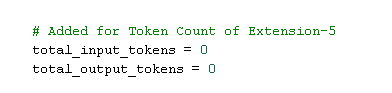

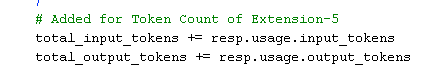

### Test Cell

In [29]:
print(
    f"Input Tokens: {total_input_tokens}"
)
print(
    f"Output Tokens: {total_output_tokens}"
)

Input Tokens: 1449
Output Tokens: 61


## Extension 6: Replace Fake Redis with Real Redis

### Real Redis Architecture
                ┌──────────────┐
                │   Claude     │
                └──────┬───────┘
                       │
                       ▼
                ┌──────────────┐
                │ FastAPI App  │
                └──────┬───────┘
                       │
                       ▼
                ┌──────────────┐
                │ Redis Server │
                └──────────────┘

### Start Redis Inside Colab

In [33]:
%%capture
!apt-get update -qq
!apt-get install redis-server -qq

In [34]:
!redis-server --daemonize yes

In [35]:
!redis-cli ping

PONG


In [38]:
import redis

r = redis.Redis(
    host="localhost",
    port=6379,
    decode_responses=True
)

print(r.ping())

True


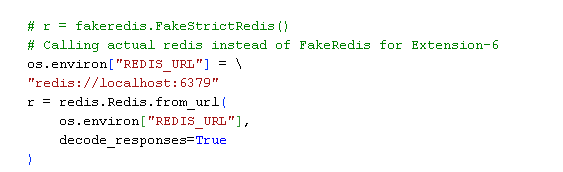

### Test Cell

In [41]:
print("========== REDIS TEST ==========")
print("Ping:", r.ping())

mem.set_fact("name", "Kapil")
print("Fact:", mem.get_fact("name"))

mem.set_fact("city", "Hyderabad")
print("All Facts:", mem.all_facts())

mem.append_turn("user", "Hello")
mem.append_turn("assistant", "Hi")

print("History:")
print(mem.load_history())

print("Redis Keys:")
print(r.keys("*"))

print("========== SUCCESS ==========")

========== REDIS TEST ==========
Ping: True
Fact: Kapil
All Facts: {'name': 'Kapil', 'city': 'Hyderabad'}
History:
[{'role': 'user', 'content': 'hello'}, {'role': 'user', 'content': 'hello'}, {'role': 'user', 'content': 'Hello'}, {'role': 'assistant', 'content': 'Hi'}]
Redis Keys:
['hist:demo-user', 'facts:demo-user']
========== SUCCESS ==========
